### Training For Baseline Without Optimizer

In [11]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Import model, modelIO
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_sgd import LSTMModelGPUSGD, GPU_AVAILABLE
from src.utils.model_io import save_model, load_and_build_model

# Export path
CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/lstm_baseline.pkl')
print(CHECKPOINT_PATH)


c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl


In [12]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [13]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

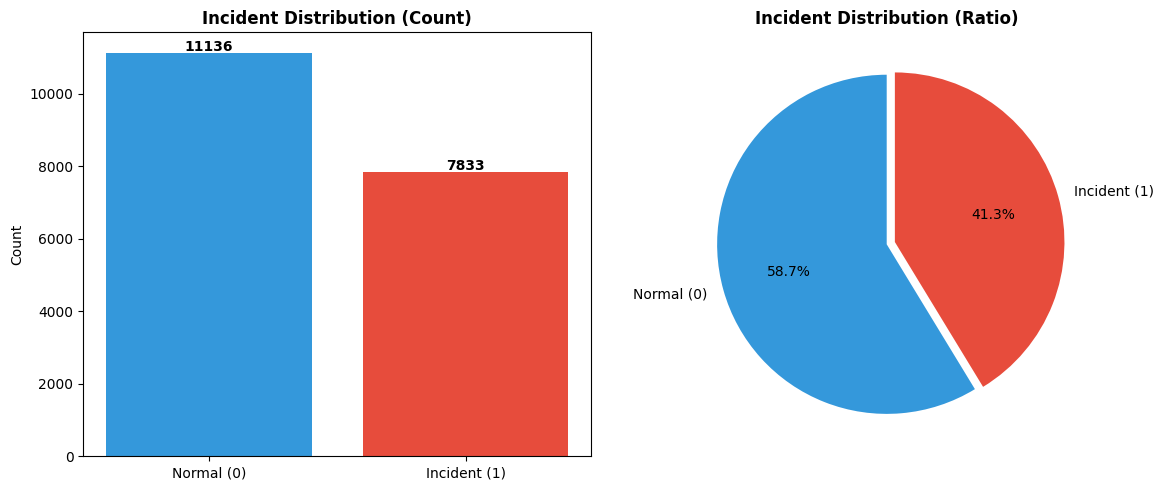


📊 Summary:
   Normal (0): 11,136 (58.7%)
   Incident (1): 7,833 (41.3%)
   Ratio: 1 : 1.4


In [14]:
# === 2.1 Check incident feature ratio ===
# Count values
counts = df['incident'].value_counts()
labels = ['Normal (0)', 'Incident (1)']
# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
axes[0].bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=['#3498db', '#e74c3c'])
axes[0].set_title('Incident Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
# Pie chart
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=labels, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c'], explode=(0, 0.05), startangle=90)
axes[1].set_title('Incident Distribution (Ratio)', fontweight='bold')
plt.tight_layout()
plt.show()
# Print summary
print(f"\n📊 Summary:")
print(f"   Normal (0): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Incident (1): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"   Ratio: 1 : {counts.get(0, 0)/max(counts.get(1, 0), 1):.1f}")

In [15]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)
        

In [16]:
# === 4. Training ===
def train_eval(X, y, label, cw=1, hidden_size=128, patience=10, epochs=100, batch_size=128, lr=0.01, print_every=1, lambda_l2=0):
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Export training, val, test sets
    export_dir = '../data/splits'
    os.makedirs(export_dir, exist_ok=True)
    
    np.save(f'{export_dir}/X_train.npy', X_tr)
    np.save(f'{export_dir}/X_val.npy', X_val)
    np.save(f'{export_dir}/X_test.npy', X_te)
    np.save(f'{export_dir}/y_train.npy', y_tr)
    np.save(f'{export_dir}/y_val.npy', y_val)
    np.save(f'{export_dir}/y_test.npy', y_te)
    print(f"💾 Datasets exported to {export_dir}/")
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Initialize Model with class weight
    model = LSTMModelGPUSGD(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    
    # Thresholding (Default 0.5)
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save the model parameters
    save_model(model, os.path.join(CHECKPOINT_PATH))
    # Calculate metrics and return the requested arrays
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'ClassWeight': cw,
        'y_test': y_te,    # Ditambahkan sesuai permintaan
        'y_pred': y_pred,  # Ditambahkan sesuai permintaan
        'y_prob': y_prob   # Bonus: probabilitas mentah untuk analisis threshold nanti
    }


Sampling Period: 30min

  Window Size: 12
    Data: 14628 samples, Class 0: 10137, Class 1: 4491
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 5388 samples, 43 batches/epoch, batch_size=128
Validation: 1797 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.7126 | Val Loss: 0.7028 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6965 | Val Loss: 0.6903 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6853 | Val Loss: 0.6813 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6783 | Val Loss: 0.6748 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6726 | Val Loss: 0.6694 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6658 | Val Loss: 0.6644 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6593 | Val Loss: 0.6596 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    8/100 | Train Loss

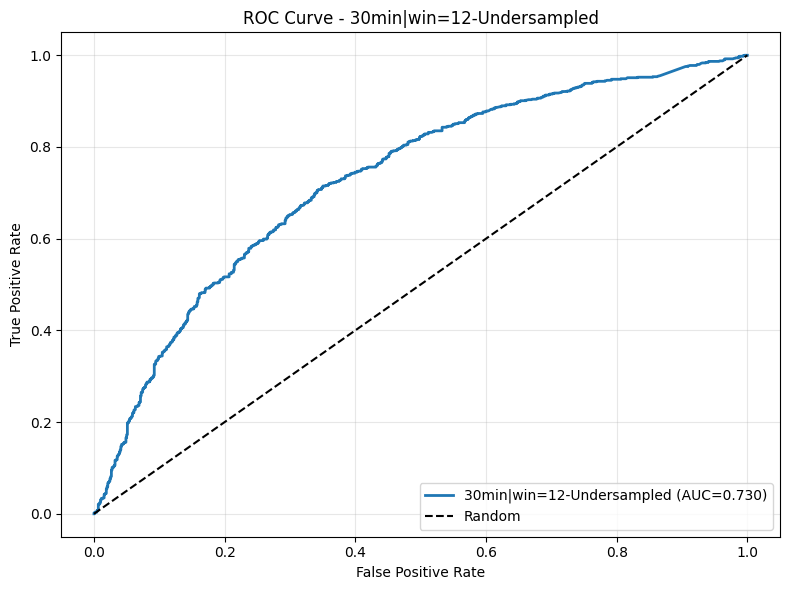

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6790 | Val Loss: 0.6714 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6663 | Val Loss: 0.6604 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6575 | Val Loss: 0.6514 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6494 | Val Loss: 0.6434 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6420 | Val Loss: 0.6360 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6353 | Val Loss: 0.6293 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6290 | Val Loss: 0.6232 | Val Acc: 0.5001 [UN

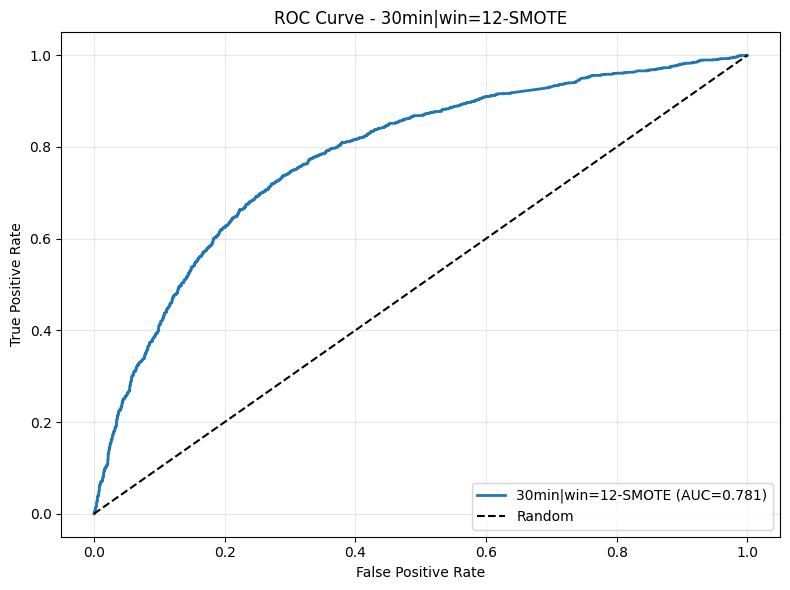

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 2.26x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 8776 samples, 69 batches/epoch, batch_size=128
Validation: 2926 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6969 | Val Loss: 0.6993 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6992 | Val Loss: 0.6978 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6960 | Val Loss: 0.6910 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6866 | Val Loss: 0.6847 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6803 | Val Loss: 0.6761 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6714 | Val Loss: 0.6684 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6646 | Val 

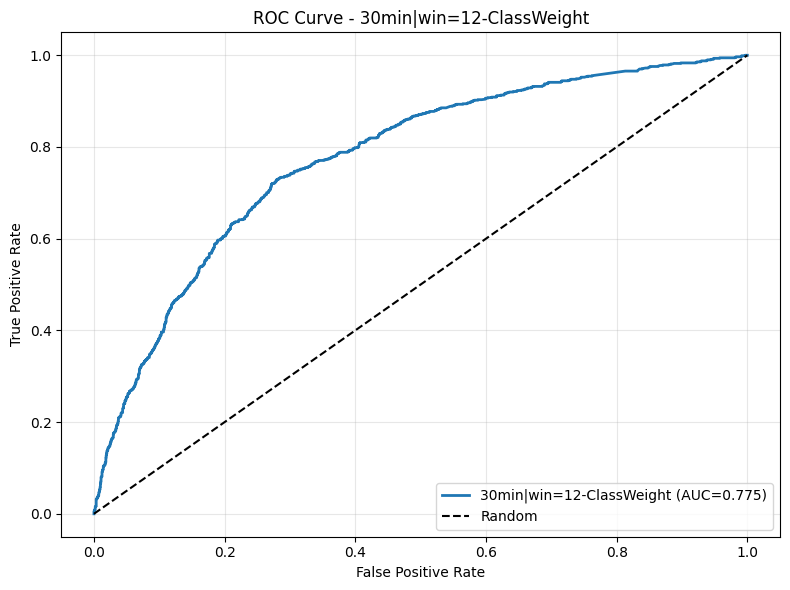

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 24
    Data: 14616 samples, Class 0: 10130, Class 1: 4486
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 5382 samples, 43 batches/epoch, batch_size=128
Validation: 1795 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6928 | Val Loss: 0.6871 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6833 | Val Loss: 0.6786 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6751 | Val Loss: 0.6716 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6690 | Val Loss: 0.6660 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6657 | Val Loss: 0.6613 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6607 | Val Loss: 0.6566 | Val Acc: 0.5003 [UNDERFITT

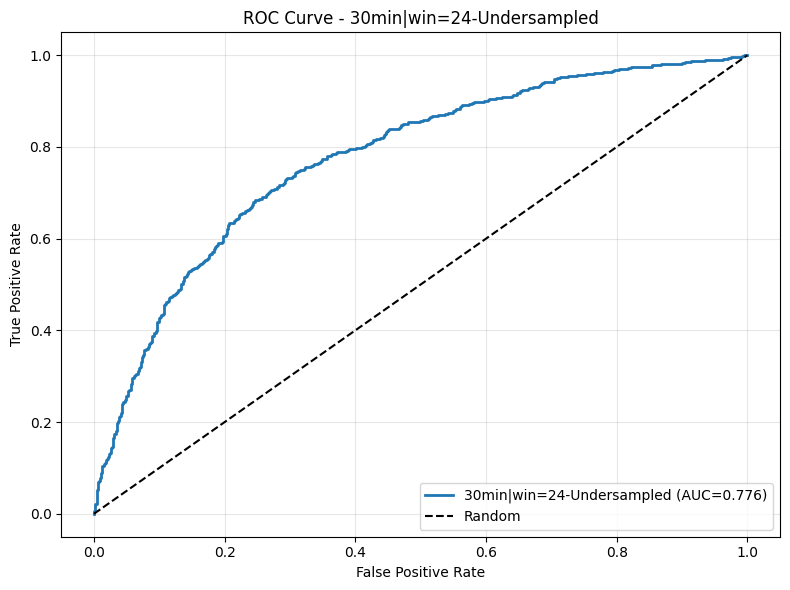

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 12156 samples, 95 batches/epoch, batch_size=128
Validation: 4052 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6987 | Val Loss: 0.6862 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6790 | Val Loss: 0.6714 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6674 | Val Loss: 0.6608 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6583 | Val Loss: 0.6519 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6503 | Val Loss: 0.6439 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6430 | Val Loss: 0.6366 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6364 | Val Loss: 0.6298 | Val Acc: 0.5000 [UN

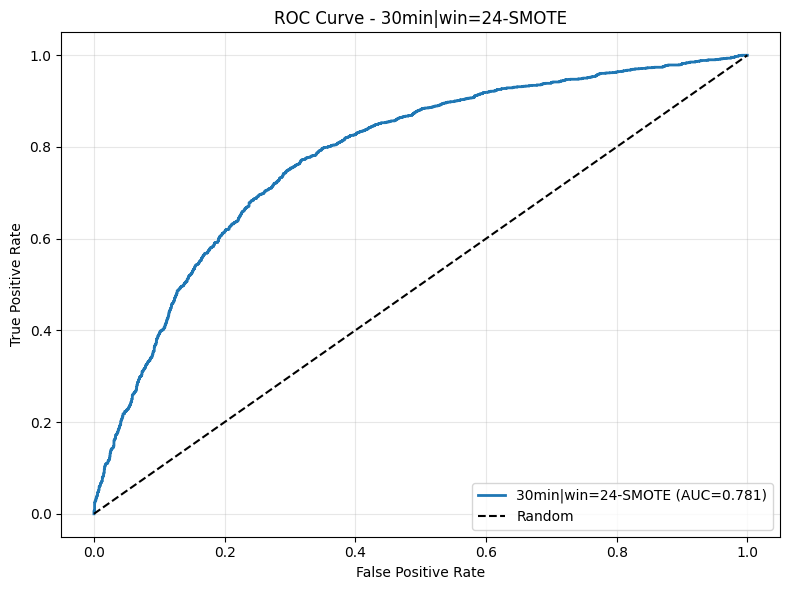

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 2.26x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 8769 samples, 69 batches/epoch, batch_size=128
Validation: 2923 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6971 | Val Loss: 0.6986 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6955 | Val Loss: 0.6960 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6884 | Val Loss: 0.6907 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6813 | Val Loss: 0.6829 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6725 | Val Loss: 0.6742 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6645 | Val Loss: 0.6650 | Val Acc: 0.3069 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6530 | Val 

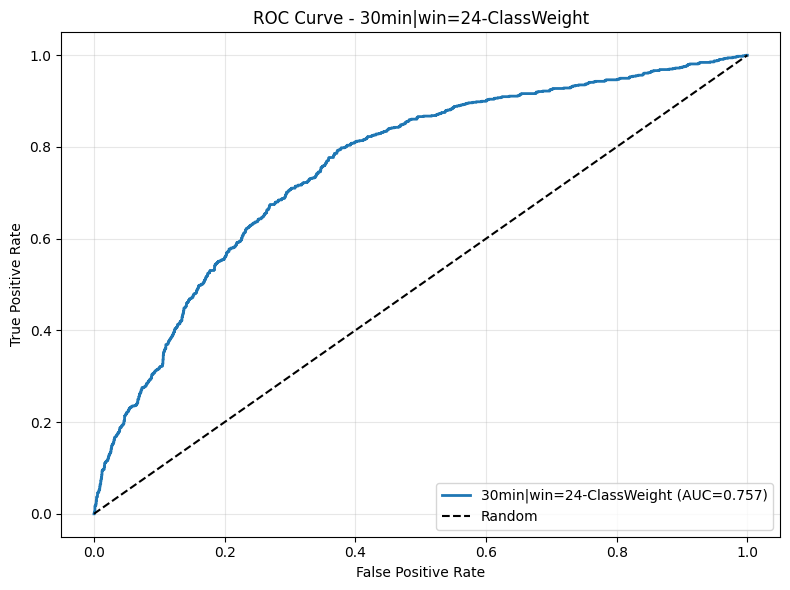

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 36
    Data: 14604 samples, Class 0: 10122, Class 1: 4482
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 5378 samples, 43 batches/epoch, batch_size=128
Validation: 1793 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6812 | Val Loss: 0.6779 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6750 | Val Loss: 0.6726 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6692 | Val Loss: 0.6679 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6644 | Val Loss: 0.6636 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6621 | Val Loss: 0.6595 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6576 | Val Loss: 0.6558 | Val Acc: 0.5003 [UNDERFITT

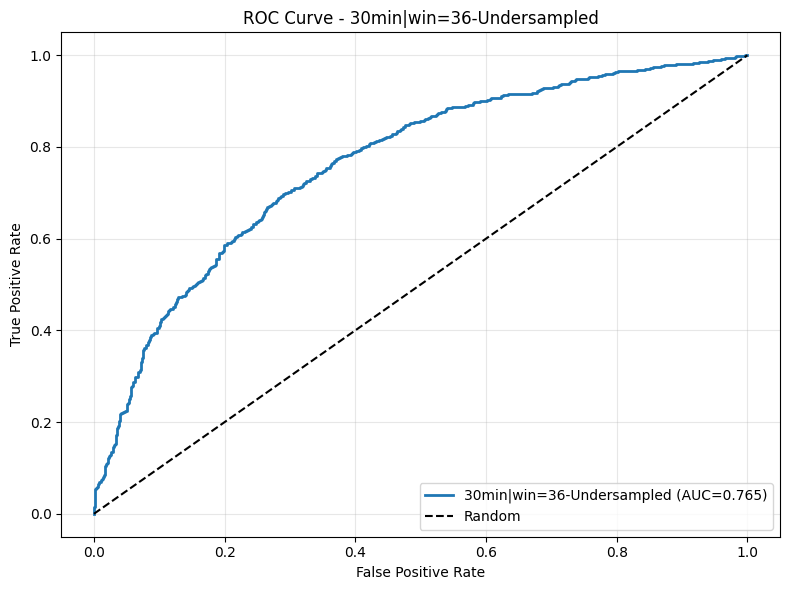

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6754 | Val Loss: 0.6704 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6646 | Val Loss: 0.6612 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6557 | Val Loss: 0.6532 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6478 | Val Loss: 0.6460 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6407 | Val Loss: 0.6395 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6342 | Val Loss: 0.6335 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6283 | Val Loss: 0.6281 | Val Acc: 0.5001 [UN

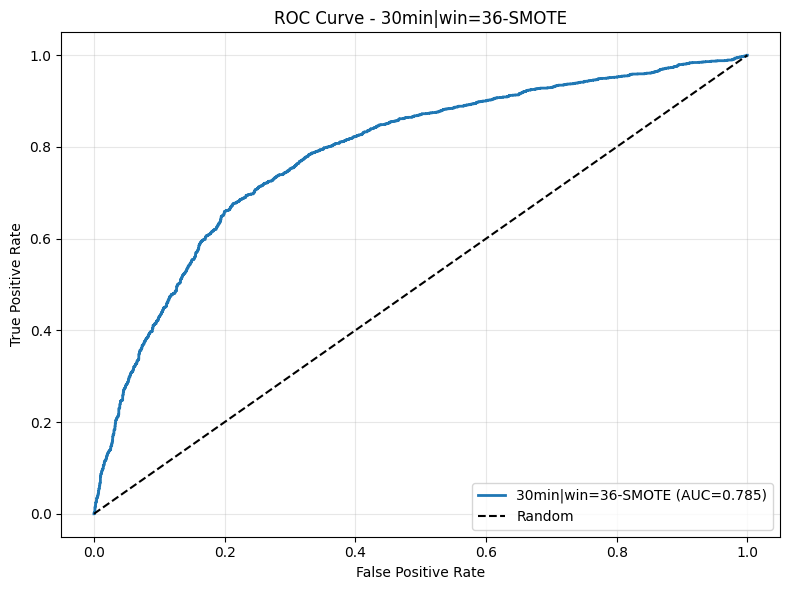

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 2.26x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 8762 samples, 69 batches/epoch, batch_size=128
Validation: 2921 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.7047 | Val Loss: 0.7004 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6964 | Val Loss: 0.6933 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6879 | Val Loss: 0.6850 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6799 | Val Loss: 0.6758 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6715 | Val Loss: 0.6667 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6616 | Val Loss: 0.6592 | Val Acc: 0.3071 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6537 | Val 

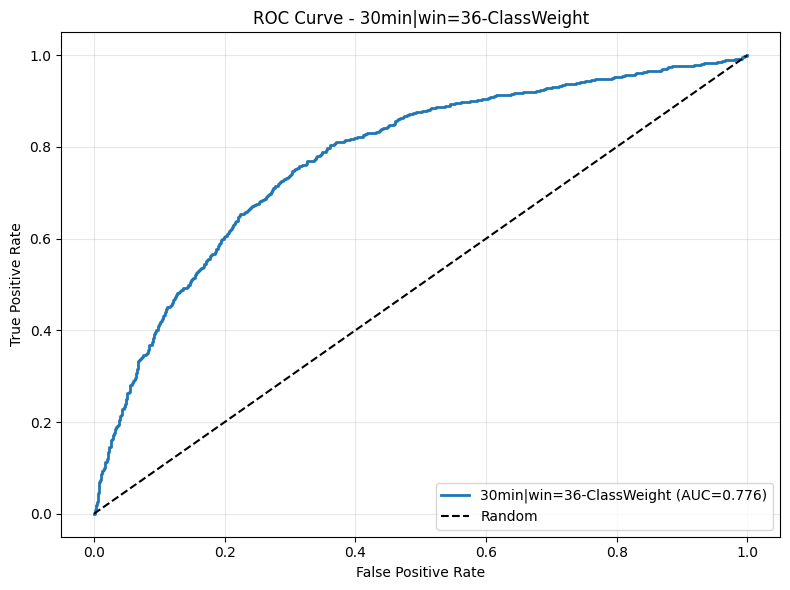

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 5376 samples, 42 batches/epoch, batch_size=128
Validation: 1792 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6940 | Val Loss: 0.6881 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6850 | Val Loss: 0.6796 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6782 | Val Loss: 0.6728 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6726 | Val Loss: 0.6670 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6678 | Val Loss: 0.6619 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6634 | Val Loss: 0.6571 | Val Acc: 0.5000 [UNDERFITT

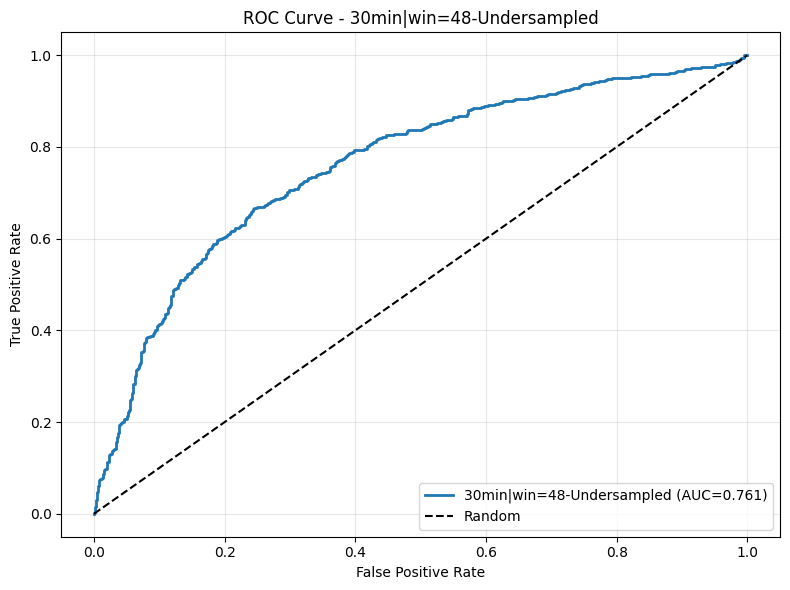

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6892 | Val Loss: 0.6788 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6737 | Val Loss: 0.6655 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6631 | Val Loss: 0.6551 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6543 | Val Loss: 0.6460 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6464 | Val Loss: 0.6377 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6391 | Val Loss: 0.6301 | Val Acc: 0.5001 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6326 | Val Loss: 0.6232 | Val Acc: 0.5001 [UN

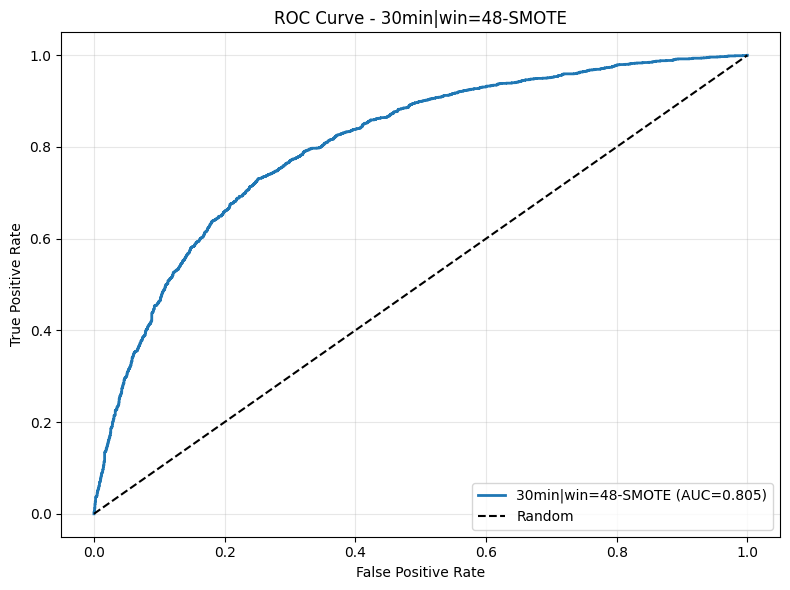

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 2.26x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 8754 samples, 69 batches/epoch, batch_size=128
Validation: 2919 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6962 | Val Loss: 0.7001 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6995 | Val Loss: 0.6970 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6931 | Val Loss: 0.6914 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6867 | Val Loss: 0.6837 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6781 | Val Loss: 0.6754 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6708 | Val Loss: 0.6659 | Val Acc: 0.3070 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6627 | Val 

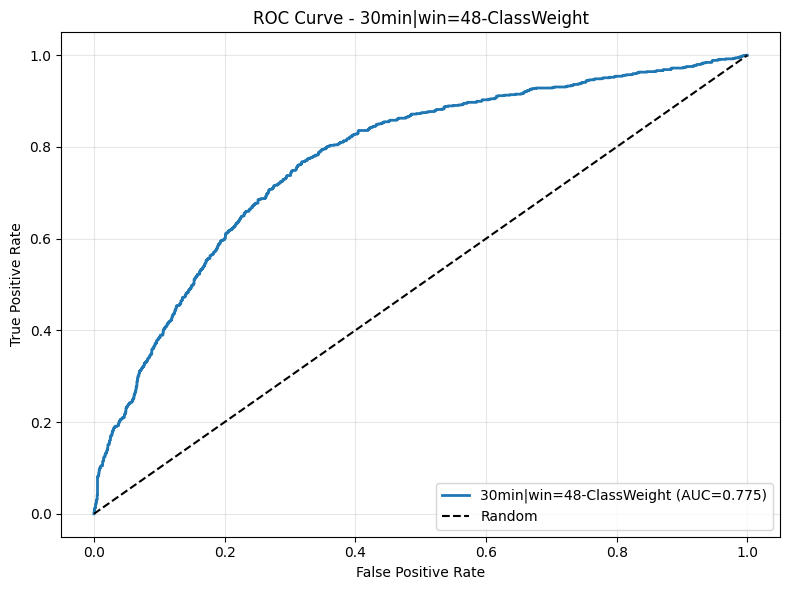

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 60
    Data: 14580 samples, Class 0: 10100, Class 1: 4480
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 5376 samples, 42 batches/epoch, batch_size=128
Validation: 1792 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6804 | Val Loss: 0.6770 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6742 | Val Loss: 0.6714 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6689 | Val Loss: 0.6666 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6642 | Val Loss: 0.6621 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6599 | Val Loss: 0.6580 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6558 | Val Loss: 0.6541 | Val Acc: 0.5000 [UNDERFITT

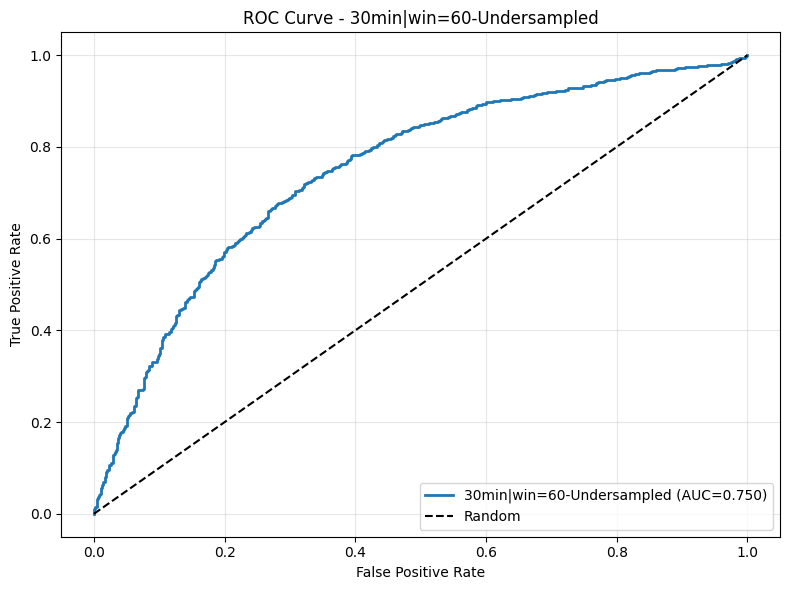

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6771 | Val Loss: 0.6712 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6658 | Val Loss: 0.6615 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6568 | Val Loss: 0.6531 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6487 | Val Loss: 0.6456 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6415 | Val Loss: 0.6387 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6347 | Val Loss: 0.6324 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6286 | Val Loss: 0.6266 | Val Acc: 0.5000 [UN

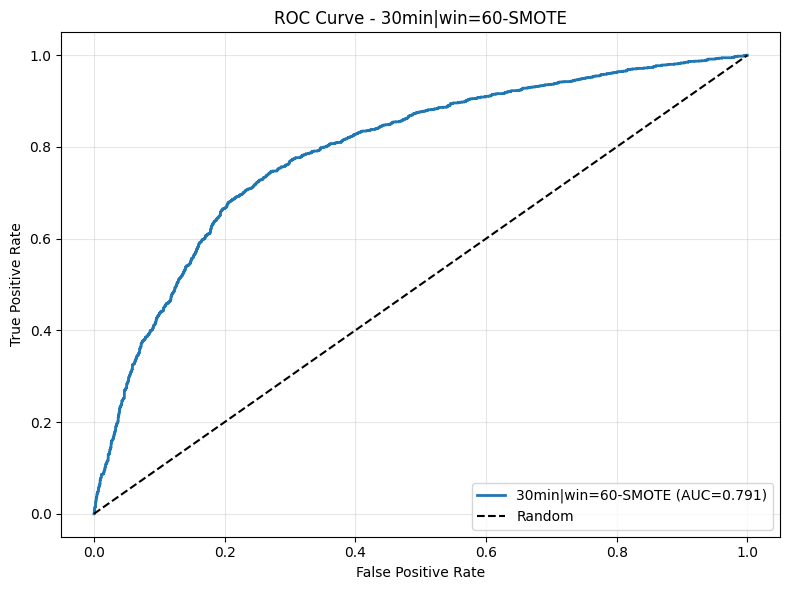

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 2.25x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 8748 samples, 69 batches/epoch, batch_size=128
Validation: 2916 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6960 | Val Loss: 0.6962 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6956 | Val Loss: 0.6946 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6953 | Val Loss: 0.6889 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6884 | Val Loss: 0.6825 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6832 | Val Loss: 0.6754 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6757 | Val Loss: 0.6684 | Val Acc: 0.3073 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6705 | Val 

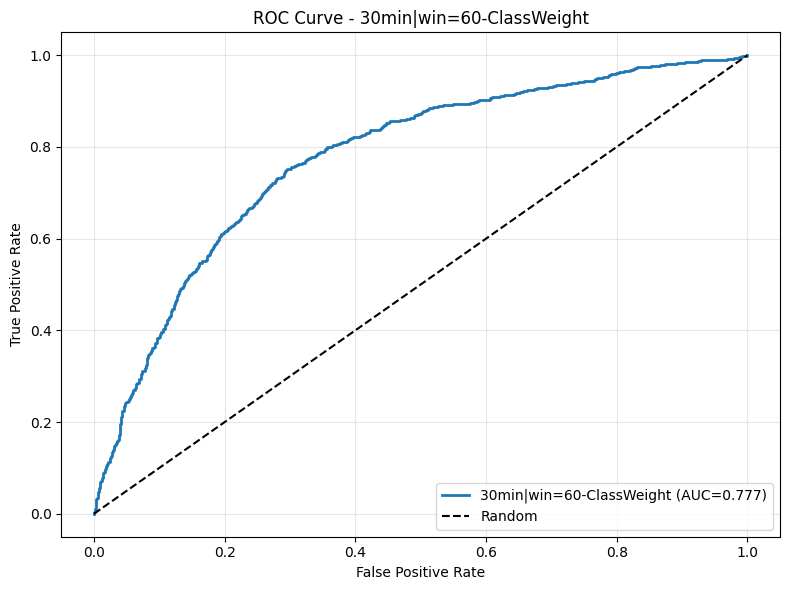

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

Sampling Period: 1h

  Window Size: 12
    Data: 7309 samples, Class 0: 3988, Class 1: 3321
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 3984 samples, 32 batches/epoch, batch_size=128
Validation: 1329 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6923 | Val Loss: 0.6896 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6874 | Val Loss: 0.6857 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6832 | Val Loss: 0.6826 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6816 | Val Loss: 0.6802 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6782 | Val Loss: 0.6778 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6756 | Val Loss: 0.6757 | Val Acc

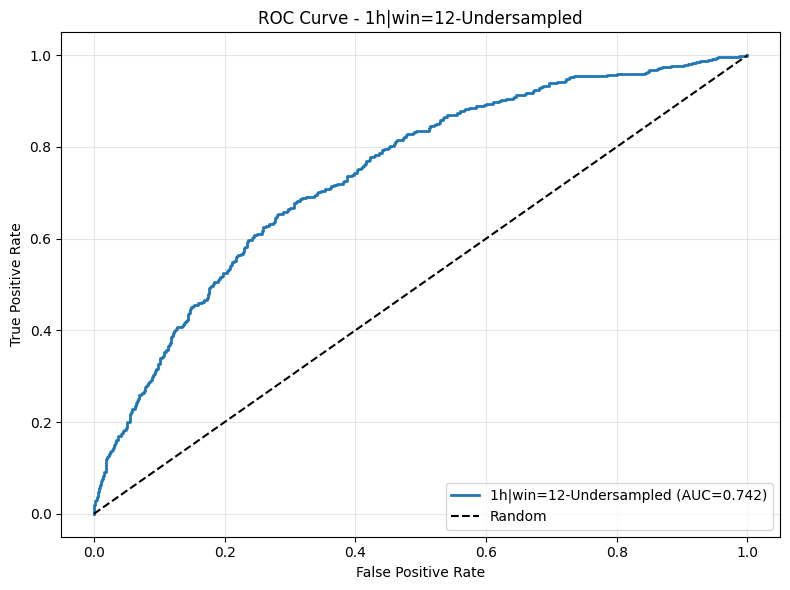

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6871 | Val Loss: 0.6845 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6825 | Val Loss: 0.6808 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6789 | Val Loss: 0.6776 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6760 | Val Loss: 0.6749 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6729 | Val Loss: 0.6722 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6704 | Val Loss: 0.6697 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6677 | Val Loss: 0.6673 | Val Acc: 0.4997 [UND

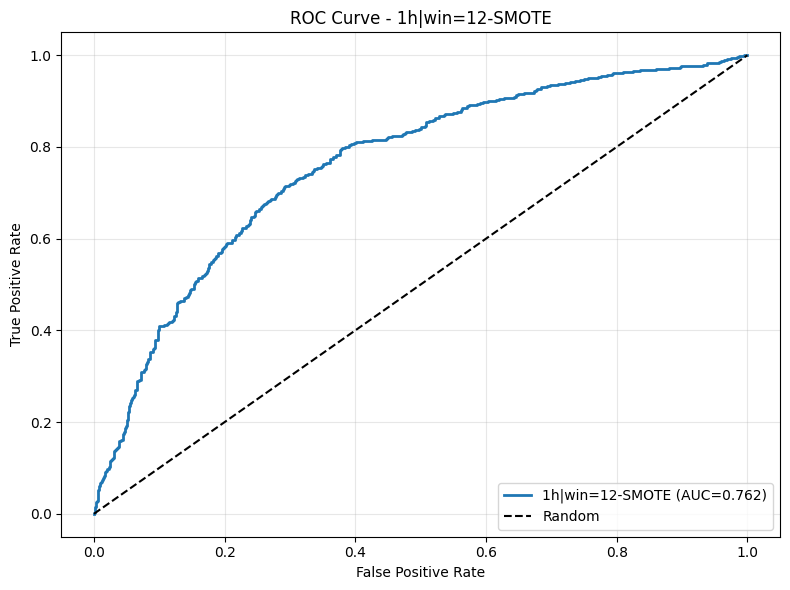

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 1.20x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 4385 samples, 35 batches/epoch, batch_size=128
Validation: 1462 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6935 | Val Loss: 0.6923 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6914 | Val Loss: 0.6900 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6893 | Val Loss: 0.6878 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6865 | Val Loss: 0.6858 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6854 | Val Loss: 0.6834 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6834 | Val Loss: 0.6809 | Val Acc: 0.4542 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6805 | Val 

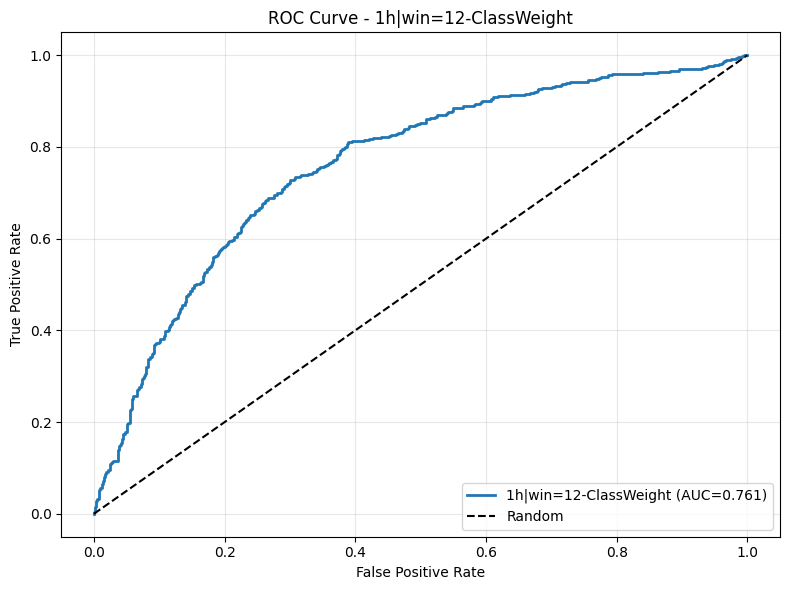

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 24
    Data: 7297 samples, Class 0: 3981, Class 1: 3316
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 3978 samples, 32 batches/epoch, batch_size=128
Validation: 1327 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6996 | Val Loss: 0.6969 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6944 | Val Loss: 0.6923 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6901 | Val Loss: 0.6885 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6866 | Val Loss: 0.6854 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6837 | Val Loss: 0.6826 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6815 | Val Loss: 0.6800 | Val Acc: 0.5004 [UNDERFITTIN

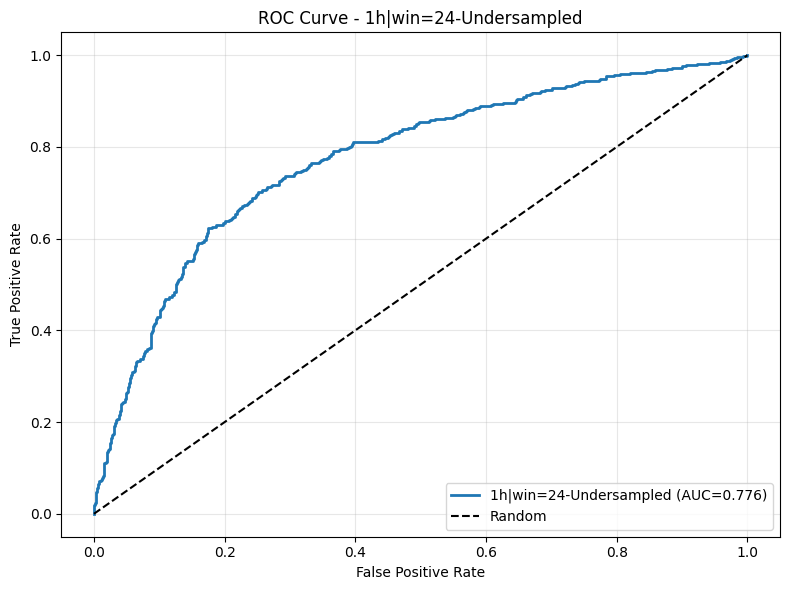

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6899 | Val Loss: 0.6891 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6869 | Val Loss: 0.6864 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6837 | Val Loss: 0.6837 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6805 | Val Loss: 0.6813 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6781 | Val Loss: 0.6789 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6754 | Val Loss: 0.6766 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6730 | Val Loss: 0.6744 | Val Acc: 0.5003 [UND

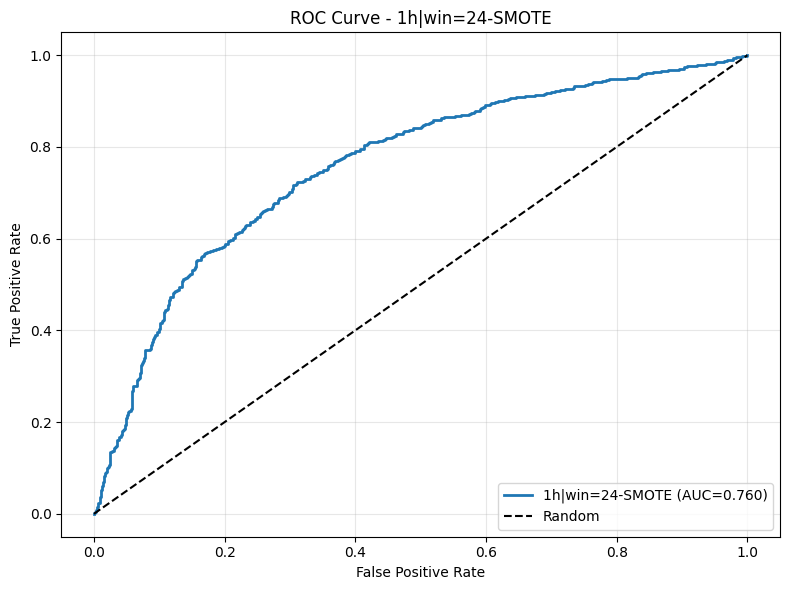

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 1.20x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 4377 samples, 35 batches/epoch, batch_size=128
Validation: 1460 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6984 | Val Loss: 0.6962 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6941 | Val Loss: 0.6930 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6915 | Val Loss: 0.6905 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6896 | Val Loss: 0.6881 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6872 | Val Loss: 0.6857 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6849 | Val Loss: 0.6833 | Val Acc: 0.4548 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6823 | Val 

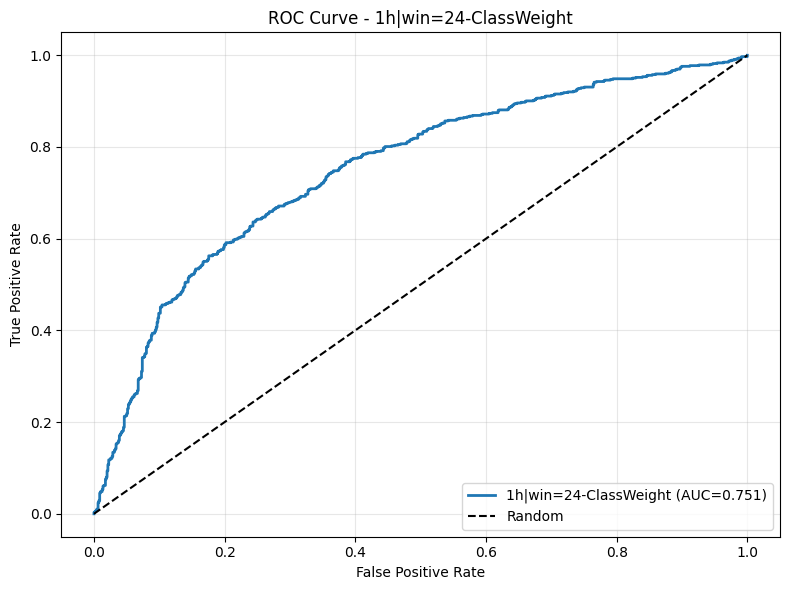

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 36
    Data: 7285 samples, Class 0: 3973, Class 1: 3312
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 3974 samples, 32 batches/epoch, batch_size=128
Validation: 1325 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6917 | Val Loss: 0.6899 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6885 | Val Loss: 0.6870 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6851 | Val Loss: 0.6843 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6821 | Val Loss: 0.6818 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6788 | Val Loss: 0.6795 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6767 | Val Loss: 0.6774 | Val Acc: 0.5004 [UNDERFITTIN

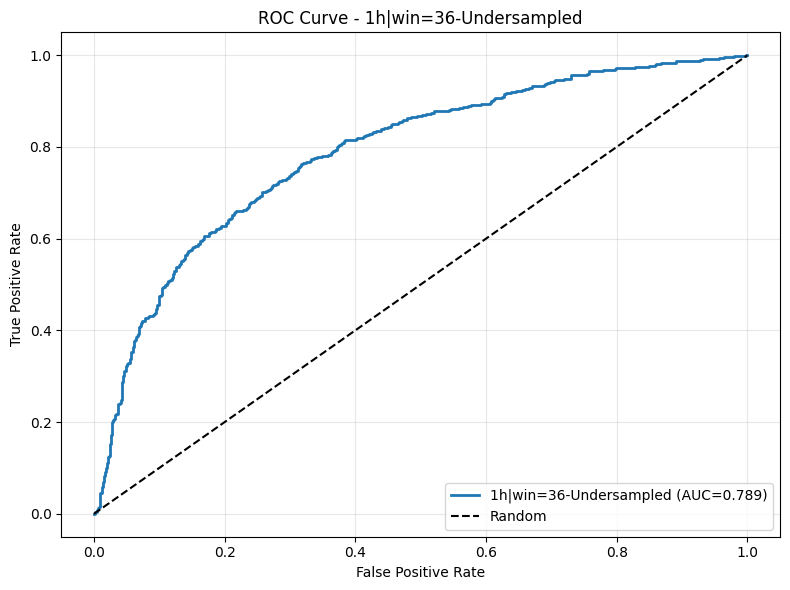

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6835 | Val Loss: 0.6814 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6809 | Val Loss: 0.6791 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6791 | Val Loss: 0.6769 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6758 | Val Loss: 0.6746 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6740 | Val Loss: 0.6725 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6722 | Val Loss: 0.6705 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6700 | Val Loss: 0.6685 | Val Acc: 0.4997 [UND

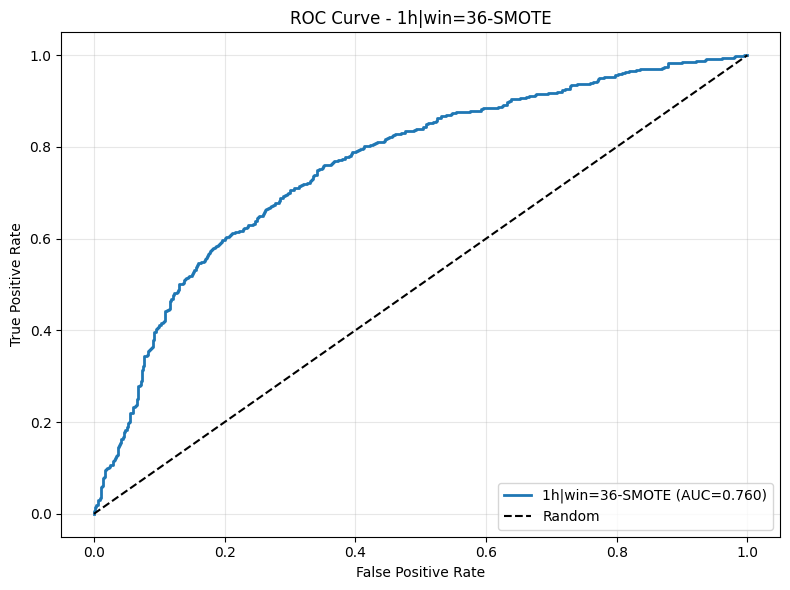

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 1.20x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 4371 samples, 35 batches/epoch, batch_size=128
Validation: 1457 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6863 | Val Loss: 0.6860 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6840 | Val Loss: 0.6844 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6826 | Val Loss: 0.6827 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6808 | Val Loss: 0.6809 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6784 | Val Loss: 0.6793 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6765 | Val Loss: 0.6774 | Val Acc: 0.4544 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6747 | Val 

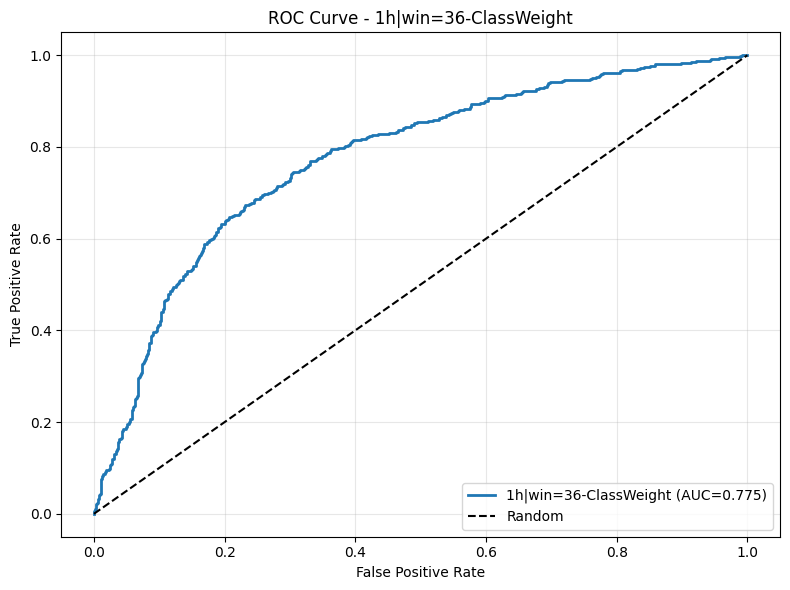

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 48
    Data: 7273 samples, Class 0: 3967, Class 1: 3306
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 3966 samples, 31 batches/epoch, batch_size=128
Validation: 1323 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.7066 | Val Loss: 0.7027 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.7004 | Val Loss: 0.6975 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6959 | Val Loss: 0.6936 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6925 | Val Loss: 0.6904 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6896 | Val Loss: 0.6876 | Val Acc: 0.5004 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6870 | Val Loss: 0.6852 | Val Acc: 0.5004 [UNDERFITTIN

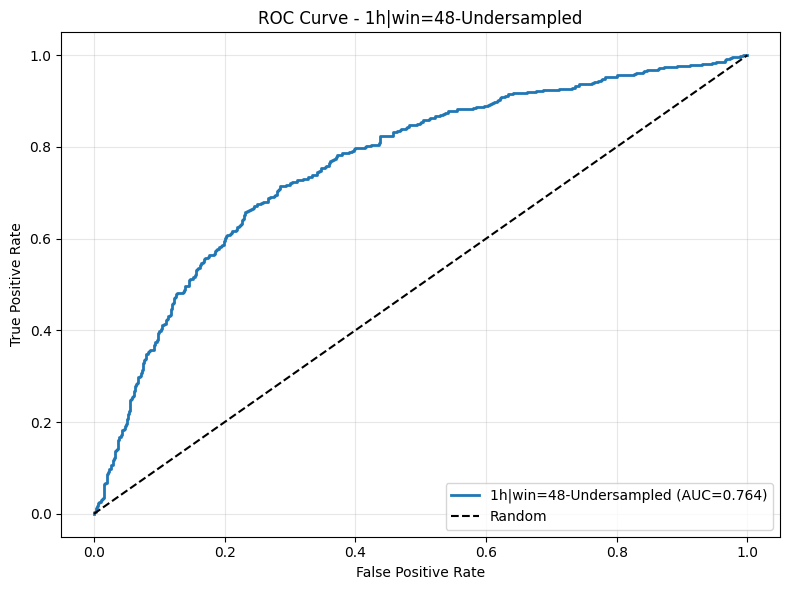

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 4760 samples, 38 batches/epoch, batch_size=128
Validation: 1587 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6900 | Val Loss: 0.6875 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6854 | Val Loss: 0.6836 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6815 | Val Loss: 0.6804 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6782 | Val Loss: 0.6775 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6753 | Val Loss: 0.6749 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6724 | Val Loss: 0.6724 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6704 | Val Loss: 0.6701 | Val Acc: 0.5003 [UND

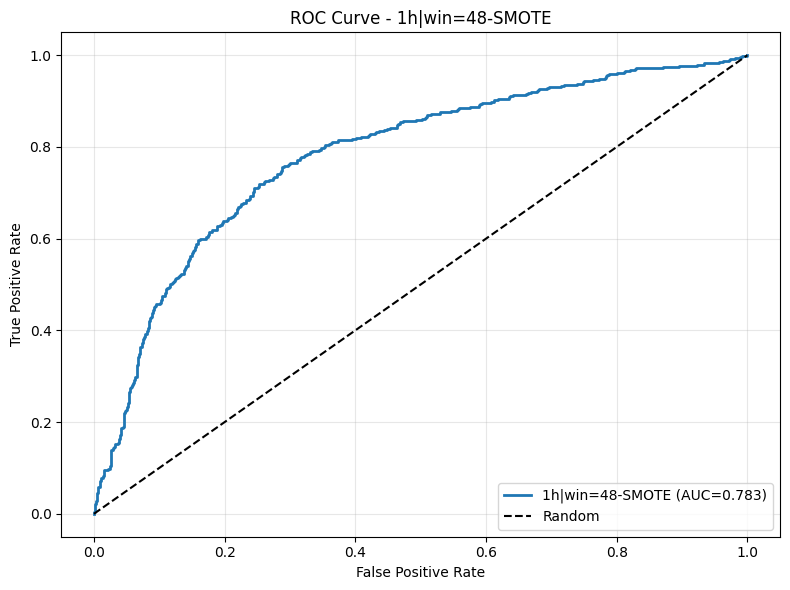

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 1.20x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 4363 samples, 35 batches/epoch, batch_size=128
Validation: 1455 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6944 | Val Loss: 0.6923 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6912 | Val Loss: 0.6894 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6884 | Val Loss: 0.6871 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6860 | Val Loss: 0.6850 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6840 | Val Loss: 0.6827 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6820 | Val Loss: 0.6802 | Val Acc: 0.4543 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6783 | Val 

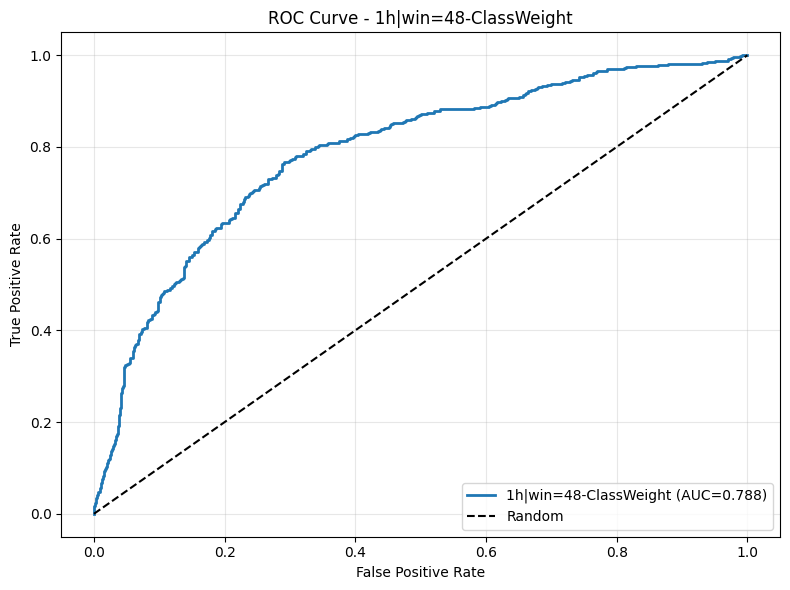

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 60
    Data: 7261 samples, Class 0: 3957, Class 1: 3304
    → Running Undersampling...
💾 Datasets exported to ../data/splits/
Training (SGD): 3964 samples, 31 batches/epoch, batch_size=128
Validation: 1322 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6854 | Val Loss: 0.6843 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6826 | Val Loss: 0.6817 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6801 | Val Loss: 0.6794 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6778 | Val Loss: 0.6773 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6757 | Val Loss: 0.6753 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6736 | Val Loss: 0.6734 | Val Acc: 0.5000 [UNDERFITTIN

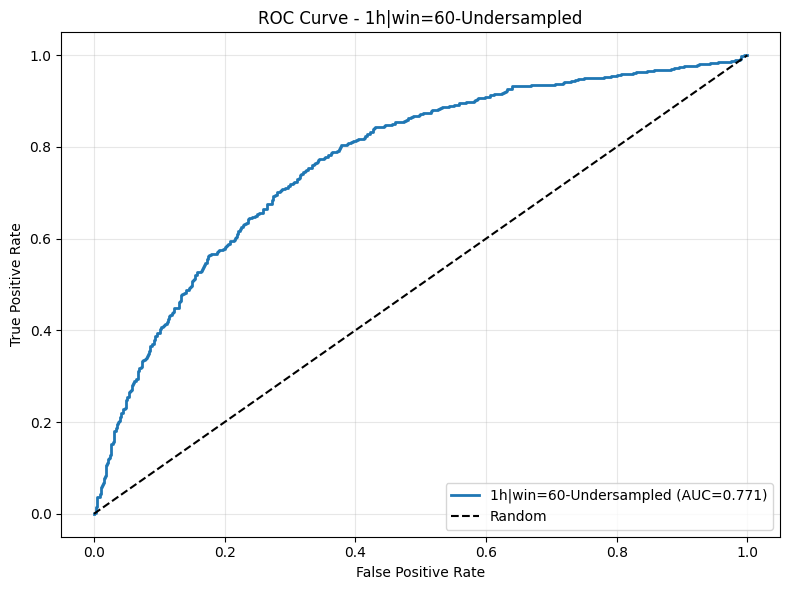

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 4748 samples, 38 batches/epoch, batch_size=128
Validation: 1583 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6875 | Val Loss: 0.6858 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6844 | Val Loss: 0.6828 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6806 | Val Loss: 0.6799 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6785 | Val Loss: 0.6774 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6768 | Val Loss: 0.6749 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6727 | Val Loss: 0.6725 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6706 | Val Loss: 0.6701 | Val Acc: 0.5003 [UND

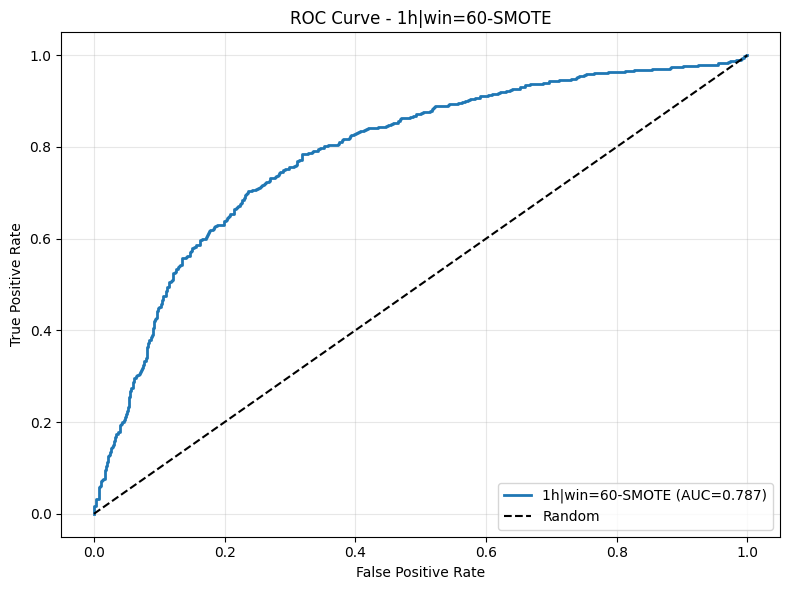

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 1.20x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 4356 samples, 35 batches/epoch, batch_size=128
Validation: 1452 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6829 | Val Loss: 0.6828 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6791 | Val Loss: 0.6811 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6791 | Val Loss: 0.6785 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6747 | Val Loss: 0.6760 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6732 | Val Loss: 0.6734 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6689 | Val Loss: 0.6708 | Val Acc: 0.4552 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6690 | Val 

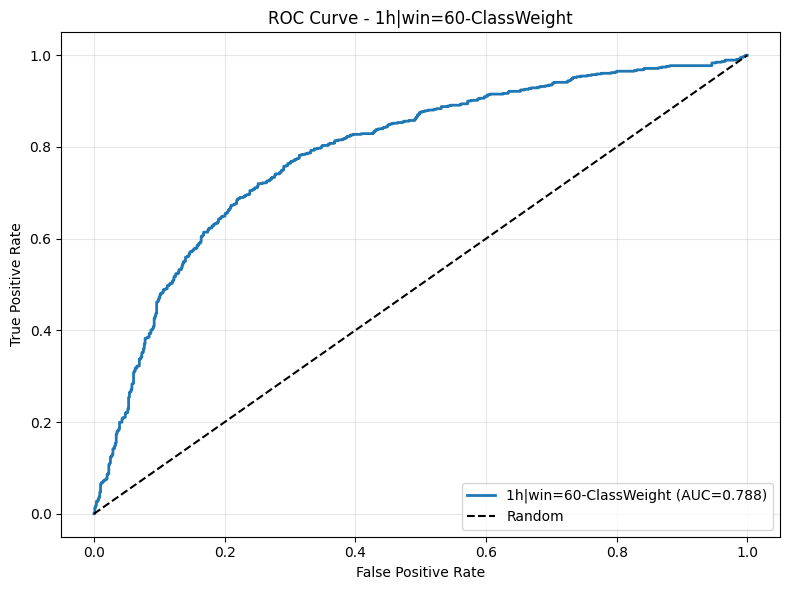

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

Sampling Period: 2h

  Window Size: 12
    Data: 3649 samples, Class 0: 1417, Class 1: 2232
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 2678 samples, 21 batches/epoch, batch_size=128
Validation: 893 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6948 | Val Loss: 0.6943 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6941 | Val Loss: 0.6937 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6935 | Val Loss: 0.6931 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6929 | Val Loss: 0.6926 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6924 | Val Loss: 0.6921 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6919 | Val Loss: 0.6916 | Val Acc: 0.5006 

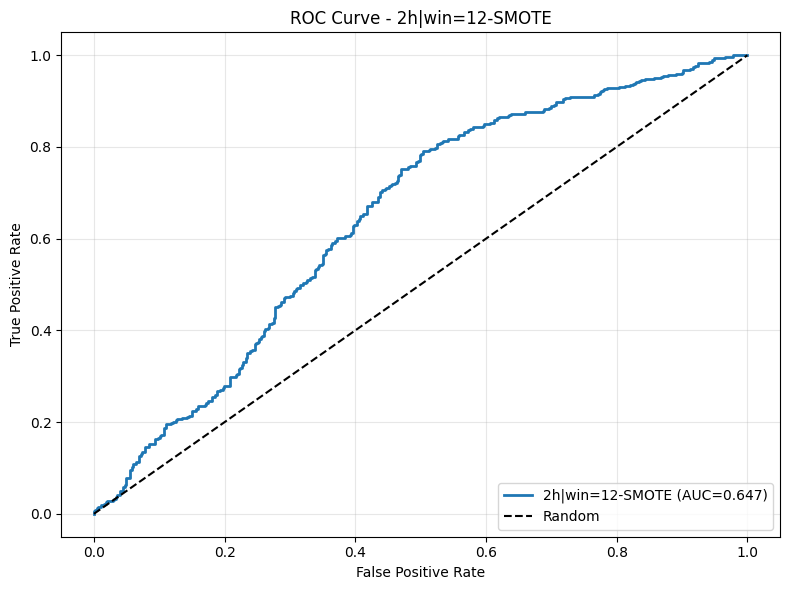

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 0.63x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 2189 samples, 18 batches/epoch, batch_size=128
Validation: 730 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6991 | Val Loss: 0.6956 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6959 | Val Loss: 0.6946 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6949 | Val Loss: 0.6931 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6935 | Val Loss: 0.6915 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6923 | Val Loss: 0.6907 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6920 | Val Loss: 0.6891 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6894 | Val L

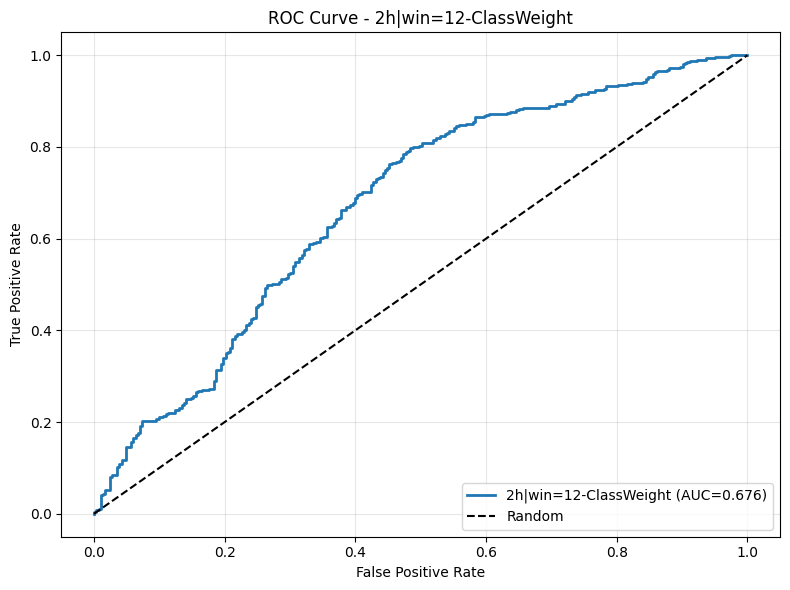

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 24
    Data: 3637 samples, Class 0: 1412, Class 1: 2225
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 2670 samples, 21 batches/epoch, batch_size=128
Validation: 890 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6966 | Val Loss: 0.6950 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6945 | Val Loss: 0.6935 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6931 | Val Loss: 0.6922 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6919 | Val Loss: 0.6913 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6910 | Val Loss: 0.6905 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6902 | Val Loss: 0.6898 | Val Acc: 0.5000 [UNDERFITTING]
Epoch 

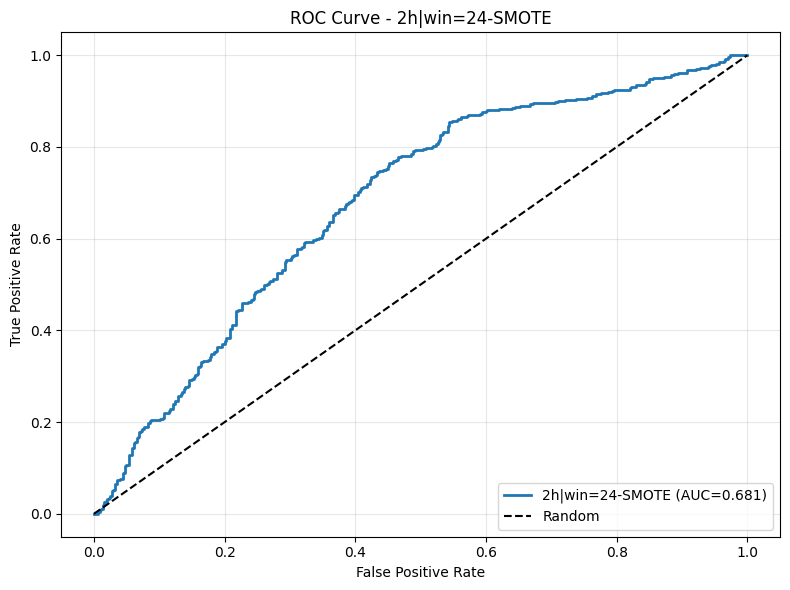

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 0.63x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 2181 samples, 18 batches/epoch, batch_size=128
Validation: 728 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6773 | Val Loss: 0.6790 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6769 | Val Loss: 0.6795 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6821 | Val Loss: 0.6815 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6809 | Val Loss: 0.6819 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6827 | Val Loss: 0.6832 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6848 | Val Loss: 0.6847 | Val Acc: 0.6113 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6842 | Val L

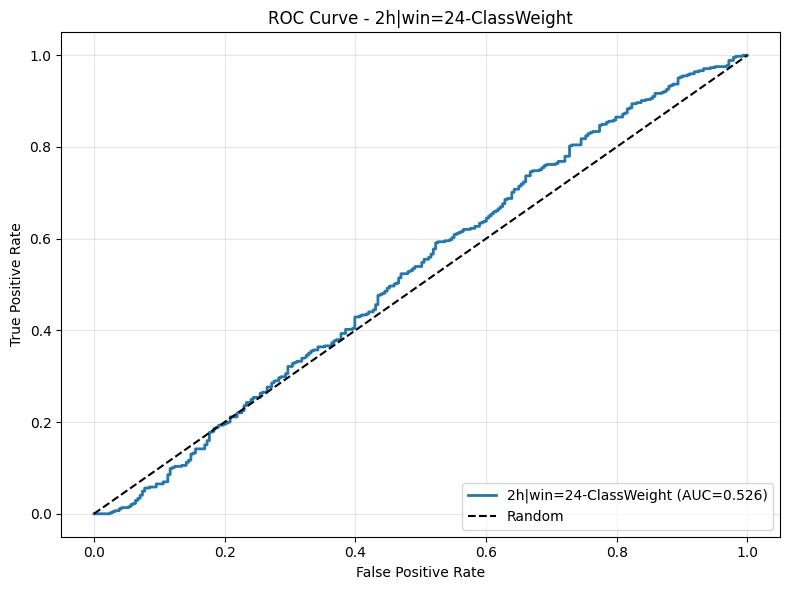

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 36
    Data: 3625 samples, Class 0: 1407, Class 1: 2218
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 2661 samples, 21 batches/epoch, batch_size=128
Validation: 887 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6977 | Val Loss: 0.6974 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6961 | Val Loss: 0.6960 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6950 | Val Loss: 0.6948 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6939 | Val Loss: 0.6939 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6932 | Val Loss: 0.6932 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6925 | Val Loss: 0.6926 | Val Acc: 0.4994 [UNDERFITTING]
Epoch 

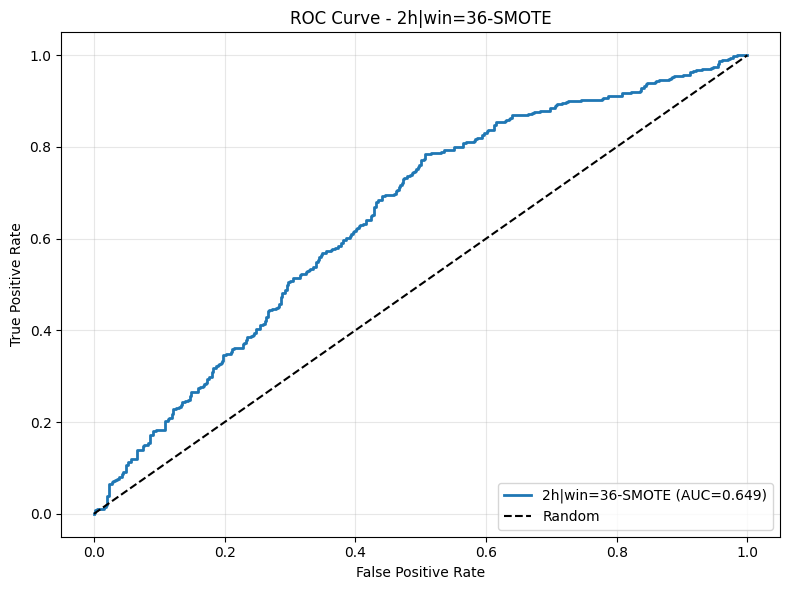

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 0.63x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 2175 samples, 17 batches/epoch, batch_size=128
Validation: 725 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6874 | Val Loss: 0.6877 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6870 | Val Loss: 0.6876 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6867 | Val Loss: 0.6874 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6868 | Val Loss: 0.6872 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6866 | Val Loss: 0.6871 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6866 | Val Loss: 0.6869 | Val Acc: 0.6110 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6861 | Val L

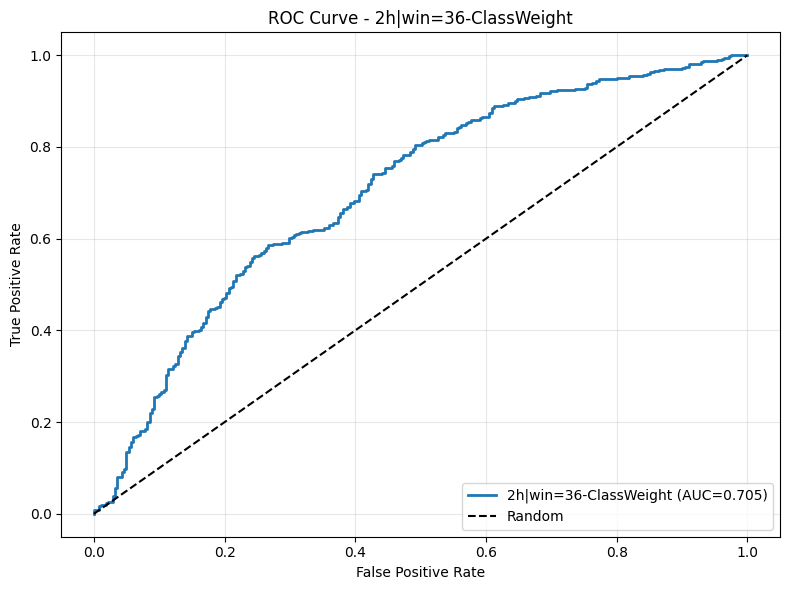

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 48
    Data: 3613 samples, Class 0: 1402, Class 1: 2211
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 2652 samples, 21 batches/epoch, batch_size=128
Validation: 885 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6899 | Val Loss: 0.6895 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6893 | Val Loss: 0.6891 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6889 | Val Loss: 0.6886 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6885 | Val Loss: 0.6882 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6880 | Val Loss: 0.6878 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6876 | Val Loss: 0.6873 | Val Acc: 0.5006 [UNDERFITTING]
Epoch 

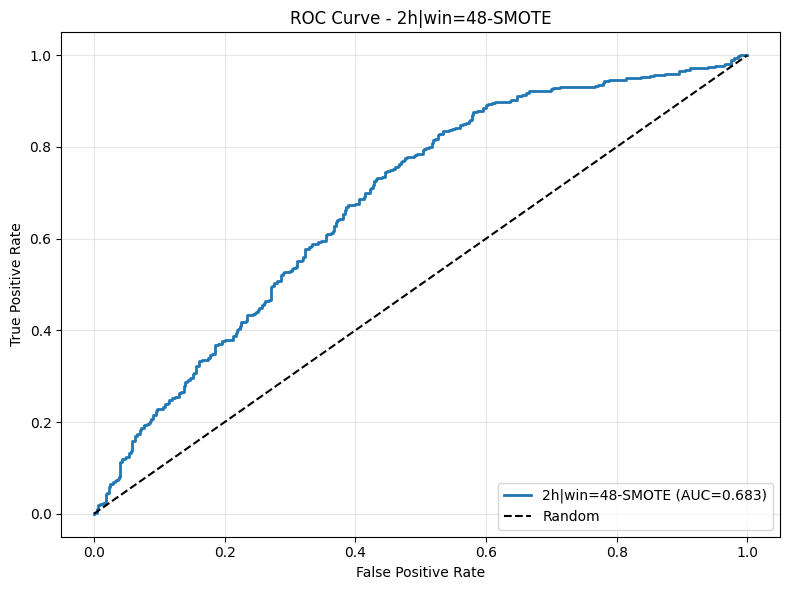

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 0.63x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 2167 samples, 17 batches/epoch, batch_size=128
Validation: 723 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.7174 | Val Loss: 0.7146 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.7120 | Val Loss: 0.7098 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.7072 | Val Loss: 0.7059 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.7038 | Val Loss: 0.7026 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.7013 | Val Loss: 0.6997 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6984 | Val Loss: 0.6973 | Val Acc: 0.6127 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6961 | Val L

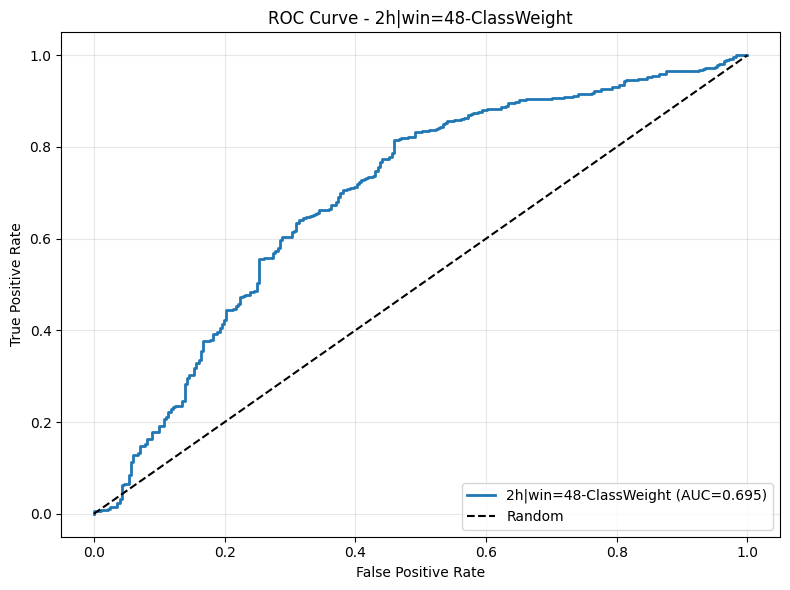

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

  Window Size: 60
    Data: 3601 samples, Class 0: 1398, Class 1: 2203
    → Running SMOTE...
💾 Datasets exported to ../data/splits/
Training (SGD): 2643 samples, 21 batches/epoch, batch_size=128
Validation: 881 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6910 | Val Loss: 0.6906 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6905 | Val Loss: 0.6901 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6900 | Val Loss: 0.6897 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6896 | Val Loss: 0.6892 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6891 | Val Loss: 0.6888 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6887 | Val Loss: 0.6884 | Val Acc: 0.4994 [UNDERFITTING]
Epoch 

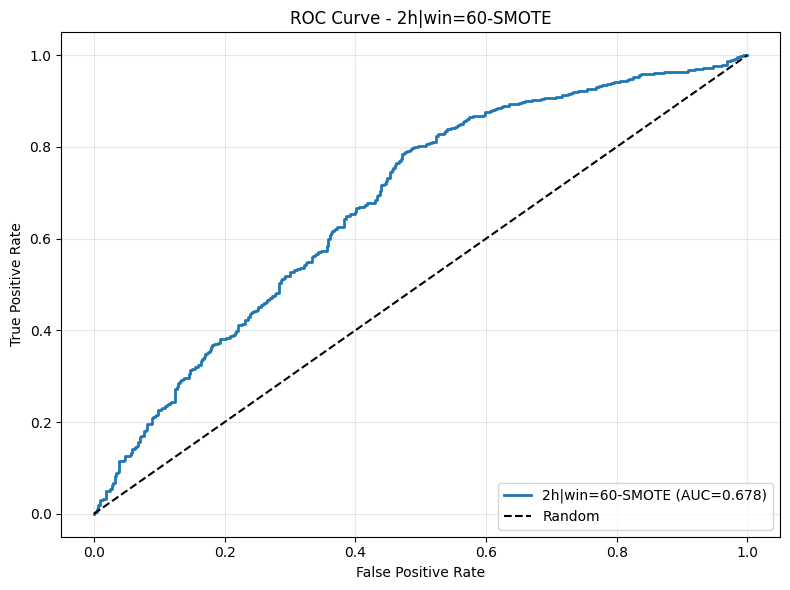

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl
    → Running with Class Weight: 0.63x for minority class
💾 Datasets exported to ../data/splits/
Training (SGD): 2160 samples, 17 batches/epoch, batch_size=128
Validation: 720 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.7038 | Val Loss: 0.7030 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.7022 | Val Loss: 0.7009 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.6997 | Val Loss: 0.6991 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.6985 | Val Loss: 0.6975 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.6967 | Val Loss: 0.6961 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.6952 | Val Loss: 0.6949 | Val Acc: 0.6111 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.6942 | Val L

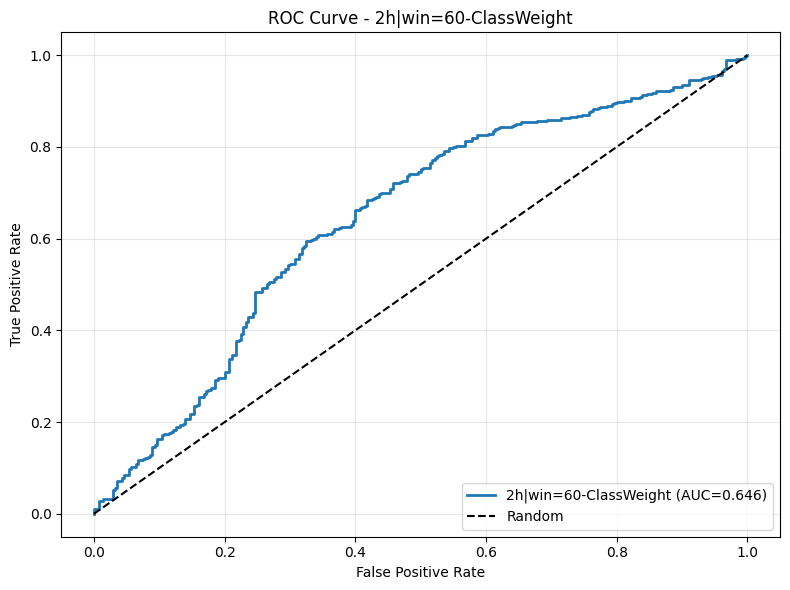

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_baseline.pkl

✅ Experiment completed! Total results: 40


In [17]:
# === 5. Run Experiment ==
sampling_periods = ['30min', '1h', '2h']
window_sizes = [12, 24, 36, 48, 60]
results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg({'incident': 'sum', 'Priority': 'mean', 'Impact': 'mean'})
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, ['Priority', 'Impact'], 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        # 1. Undersampling
        if len(maj) >= len(min_class):
            maj_down = resample(maj, replace=False, n_samples=len(min_class), random_state=42)
            under = pd.concat([maj_down, min_class])
            Xu = under.drop('label', axis=1).values.reshape((-1, win, 2))
            yu = under.label.values
            
            print(f"    → Running Undersampling...")
            result = train_eval(Xu, yu, label=f"{sp}|win={win}-Undersampled")
            results_all.append(result)

        # 2. SMOTE
        try:
            print(f"    → Running SMOTE...")
            X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
            Xs = X_sm.reshape((-1, win, 2))
            result = train_eval(Xs, y_sm, label=f"{sp}|win={win}-SMOTE")
            results_all.append(result)
        except Exception as e:
            print(f"    ✗ SMOTE failed: {e}")
            continue

        # 3. Class Weight (weighted loss on original imbalanced data)
        cw_vals = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        cw_ratio = cw_vals[1] / cw_vals[0]  # Relative weight for class 1
        print(f"    → Running with Class Weight: {cw_ratio:.2f}x for minority class")
        result = train_eval(X, y, label=f"{sp}|win={win}-ClassWeight", cw=cw_ratio)
        results_all.append(result)

print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print('='*60)




📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)


,Model,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
0,2h|win=12-ClassWeight,0.6877,0.6952,0.8725,0.7738,0.6757,69.3554
1,2h|win=36-ClassWeight,0.6897,0.7212,0.8041,0.7604,0.7051,466.7631
2,2h|win=24-ClassWeight,0.6113,0.6113,1.0000,0.7587,0.5262,36.7024
3,2h|win=48-ClassWeight,0.6860,0.7322,0.7670,0.7492,0.6946,629.7794
4,30min|win=48-SMOTE,0.7342,0.7195,0.7676,0.7428,0.8052,3473.3064
5,30min|win=60-SMOTE,0.7364,0.7349,0.7396,0.7372,0.7911,4302.6101
6,1h|win=48-SMOTE,0.7290,0.7249,0.7377,0.7312,0.7828,1720.5157
7,1h|win=60-SMOTE,0.7277,0.7239,0.7358,0.7298,0.7873,2204.5191
8,30min|win=36-SMOTE,0.7256,0.7194,0.7396,0.7294,0.7850,3113.3990
9,30min|win=24-SMOTE,0.7248,0.7187,0.7389,0.7286,0.7815,2481.0033



🎯 DETAILED ANALYSIS: 2h|win=12-ClassWeight


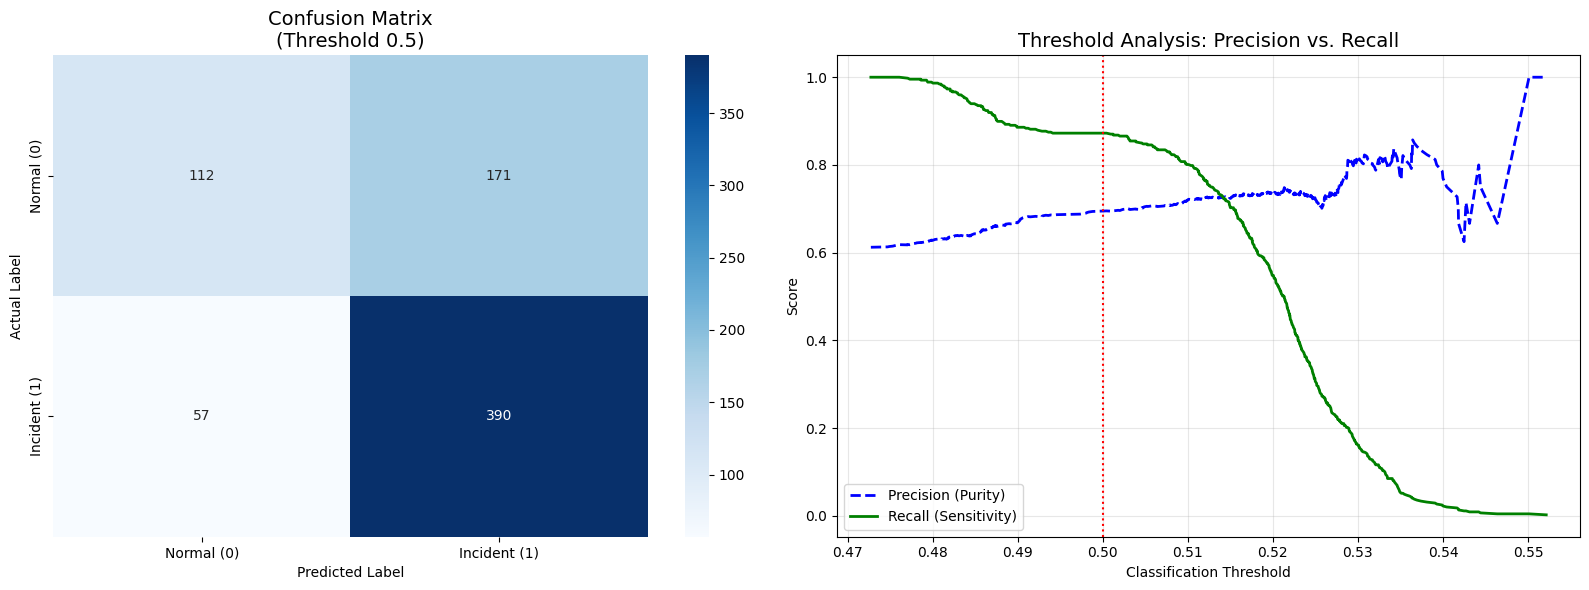


💡 RESOURCE OPTIMIZATION TIP:
   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: 0.529
   Pada titik ini, Precision akan berada di atas 80% dengan Recall sekitar 20.1%.


In [18]:
# === 6. Final Results Visualization & Comparison ===

# 1. Convert the results list to a Pandas DataFrame
res_df = pd.DataFrame(results_all)

# 2. Metadata Extraction
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].fillna(0).astype(int)
res_df['Sampling'] = res_df['Sampling'].fillna('Unknown')

# Identify Method and Type
res_df['Method'] = res_df['Model'].apply(lambda m: 'SMOTE' if 'SMOTE' in m else ('Undersampled' if 'Under' in m else ('ClassWeight' if 'ClassWeight' in m else 'Original')))
res_df['Type'] = res_df['Model'].apply(lambda m: 'GRU' if 'GRU' in m else ('Transformer' if 'Transformer' in m else 'LSTM'))

# Sort by F1_Score or AUC to find the best model for detailed analysis
res_df = res_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# --- A. Comparative Summary Table ---
print("\n" + "="*70)
print("📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)")
print("="*70)
display(res_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].round(4))

# --- B. Detailed Analysis for the BEST MODEL ---
# Ambil data dari model peringkat pertama (Best Model)
best_model_data = res_df.iloc[0]
y_true = best_model_data['y_test']
y_pred = best_model_data['y_pred']
y_prob = best_model_data['y_prob']
model_label = best_model_data['Model']

print("\n" + "="*70)
print(f"🎯 DETAILED ANALYSIS: {model_label}")
print("="*70)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Incident (1)'],
            yticklabels=['Normal (0)', 'Incident (1)'], ax=ax[0])
ax[0].set_title(f"Confusion Matrix\n(Threshold 0.5)", fontsize=14)
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# 2. Threshold Analysis (Precision vs. Recall Trade-off)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

ax[1].plot(thresholds, precisions[:-1], "b--", label="Precision (Purity)", linewidth=2)
ax[1].plot(thresholds, recalls[:-1], "g-", label="Recall (Sensitivity)", linewidth=2)
ax[1].set_xlabel("Classification Threshold")
ax[1].set_ylabel("Score")
ax[1].set_title("Threshold Analysis: Precision vs. Recall", fontsize=14)
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Tambahkan garis bantu untuk melihat dampak terhadap False Positive (Precision)
# Sesuai kebutuhan Anda: meminimalkan False Positive = Mengejar Precision Tinggi
ax[1].axvline(x=0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
plt.tight_layout()
plt.show()

# --- C. Threshold Optimization for Resource Efficiency ---
# Mencari threshold terbaik jika ingin Precision > 0.8 (Hemat Resource)
target_precision = 0.80
idx = np.where(precisions >= target_precision)[0]

if len(idx) > 0:
    opt_threshold = thresholds[idx[0]]
    opt_recall = recalls[idx[0]]
    print(f"\n💡 RESOURCE OPTIMIZATION TIP:")
    print(f"   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: {opt_threshold:.3f}")
    print(f"   Pada titik ini, Precision akan berada di atas {target_precision*100:.0f}% dengan Recall sekitar {opt_recall*100:.1f}%.")
else:
    print("\n[Notice]: Tidak ditemukan threshold yang mencapai target Precision tersebut.")